# 🛠️ Importando as bibliotecas necessárias

In [396]:
# Importando as bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 🛠️ Coleta dos Dados

In [307]:
# Carregando os dados

df = pd.read_csv('/content/dados_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [309]:
df.shape

(7043, 22)

In [310]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

# 📌 Pré-Processamento dos dados

## 🛠️ Remoção de Colunas Irrelevantes

In [311]:
df = df.drop(columns=["CustomerID"])
df.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


## ✔️ Agrupamento de No e No service

In [312]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace( 'No internet service', 'No')

## ✔️ Verificação de valores nulos

In [313]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Correlação entre variaveis numericas

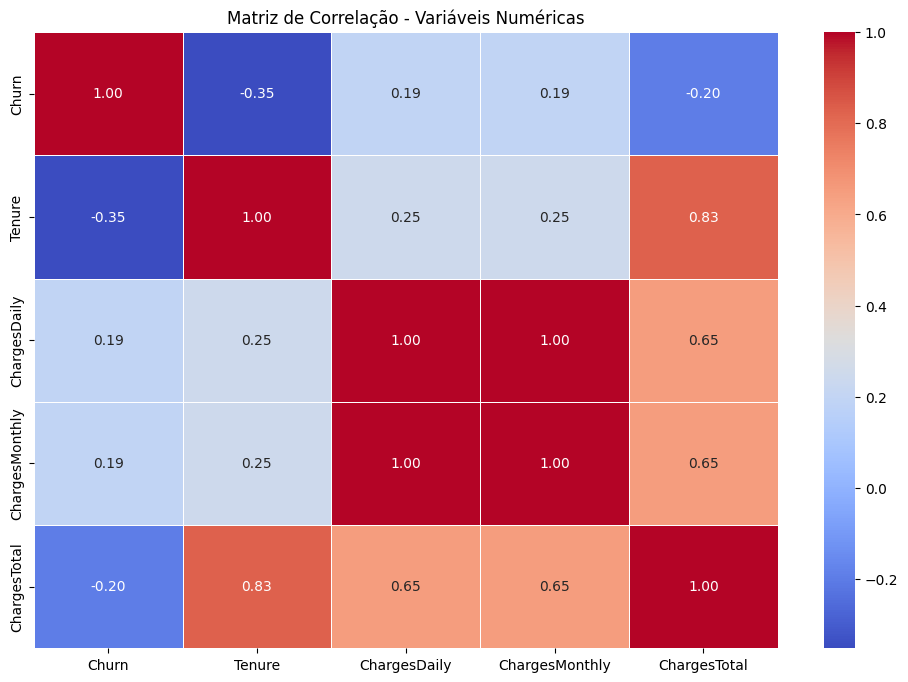

In [314]:
# Copiar dataframe para evitar warning
df_corr = df.copy()

# Converter Churn para numérico
df_corr["Churn"] = df_corr["Churn"].map({"Yes": 1, "No": 0})

# Selecionar apenas variáveis numéricas (incluindo Churn já convertida)
df_numeric = df_corr.select_dtypes(include=["int64", "float64"])

# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Plotar heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

## Análises direcionadas

In [315]:
# Proporção de Evasão

px.histogram(df, x = 'Churn', text_auto = True)

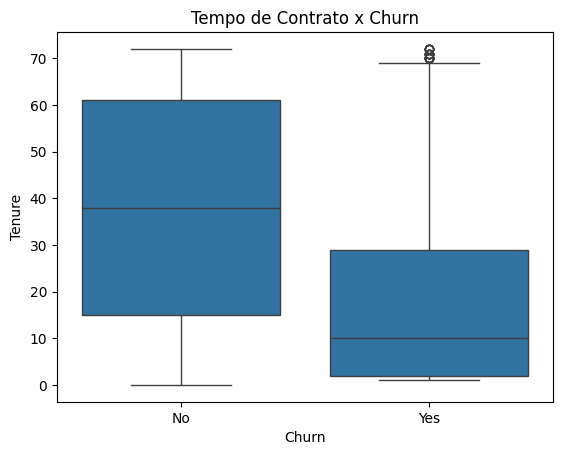

In [316]:
# Relação de Tempo de contrato x Evasão

plt.figure()
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tempo de Contrato x Churn')
plt.show()

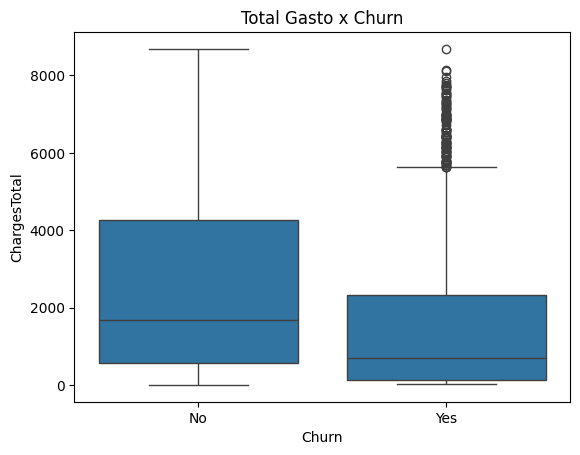

In [317]:
# Total gasto x Evasão

plt.figure()
sns.boxplot(x='Churn', y='ChargesTotal', data=df)
plt.title('Total Gasto x Churn')
plt.show()

## Tabela de proporção de evasão por categoria

In [318]:
## Verificando a proporção de Churn

# Contagem total
df['Churn'].value_counts()

# Proporção percentual
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [319]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

In [320]:
for col in categorical_cols:
    print(f"\n📌 Análise da variável: {col}")
    #Ele cria uma tabela de porcentagem de churn dentro de cada categoria de uma variável.
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Análise da variável: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Análise da variável: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Análise da variável: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Análise da variável: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Análise da variável: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


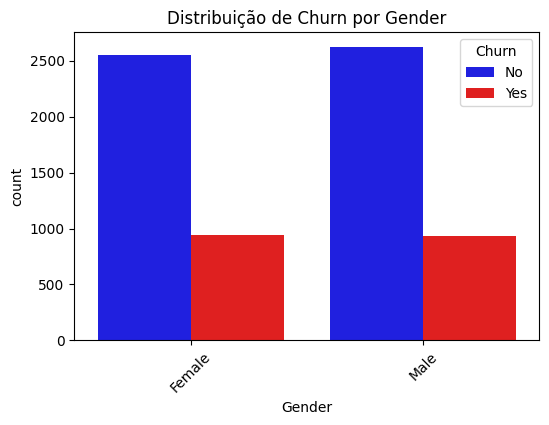

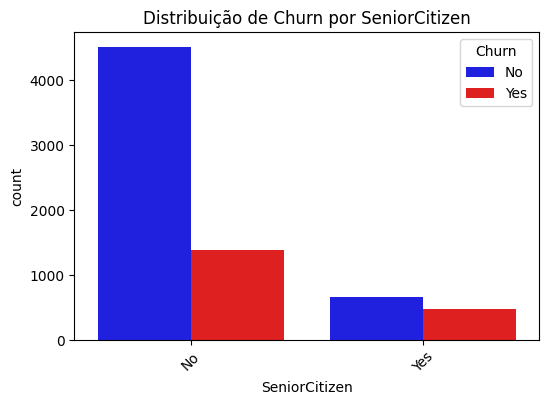

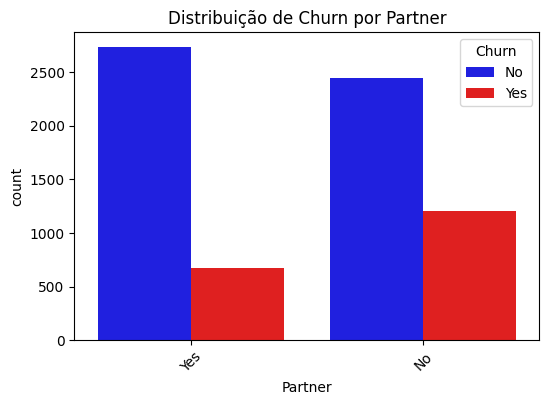

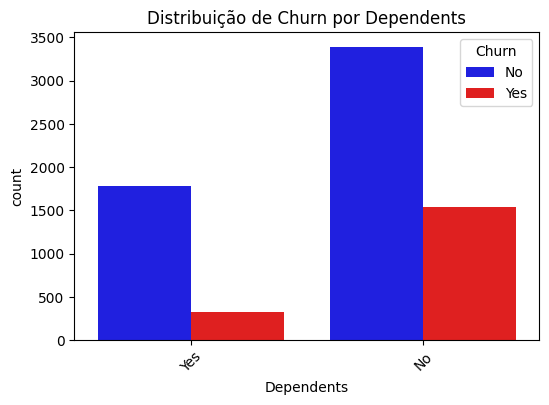

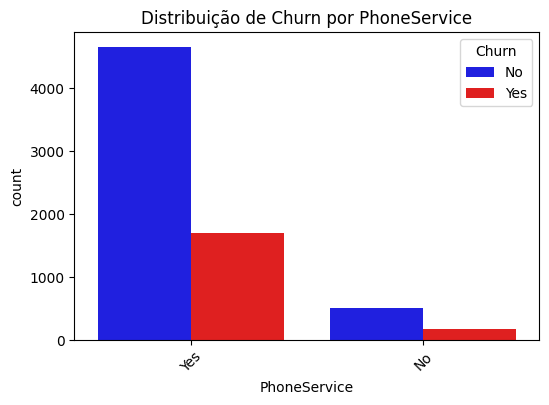

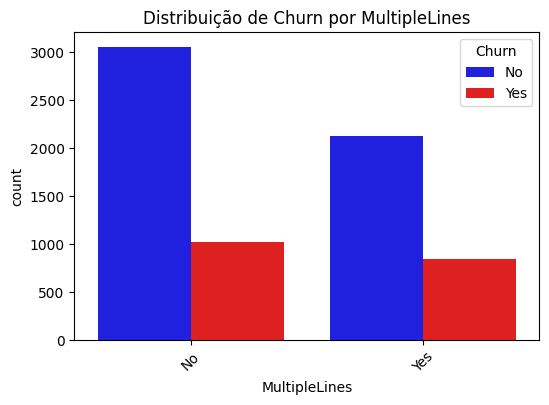

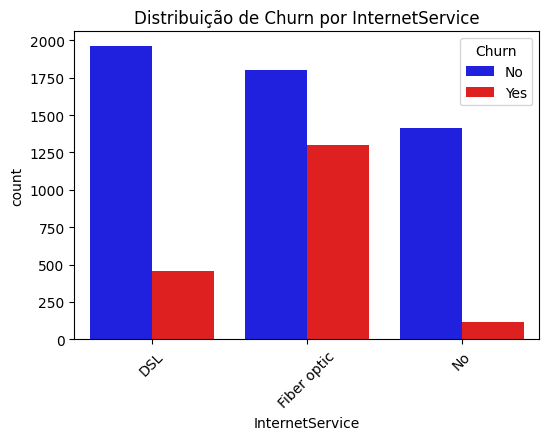

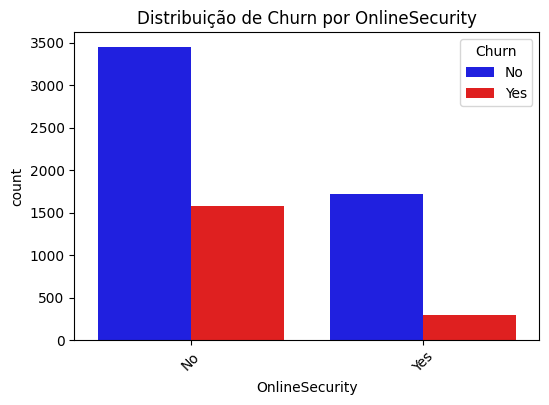

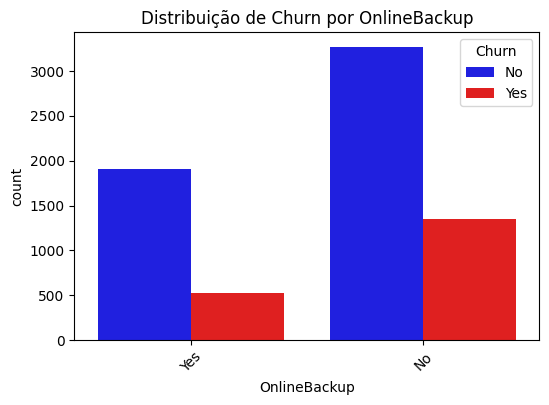

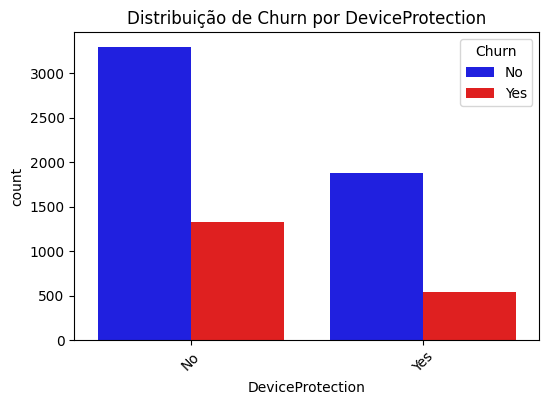

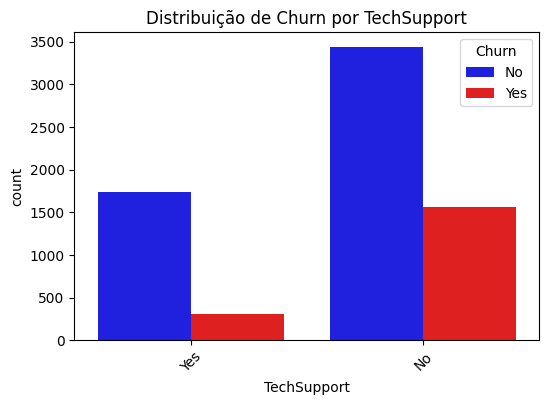

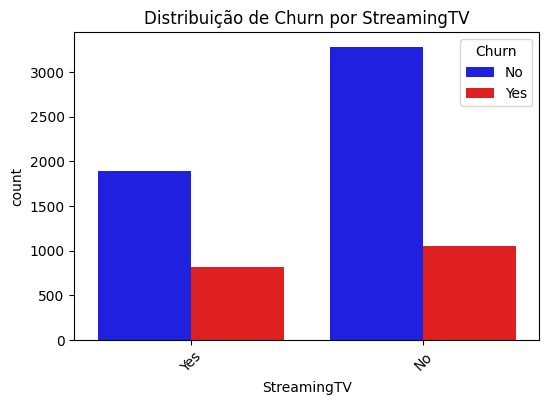

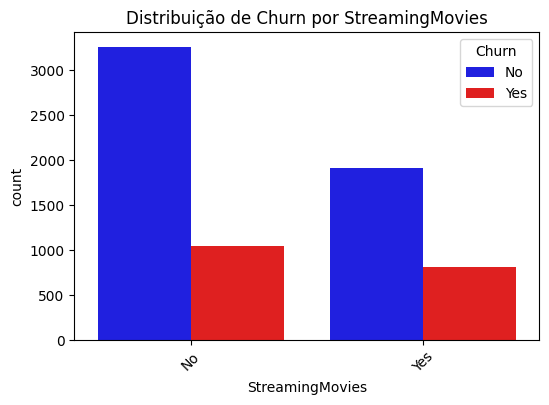

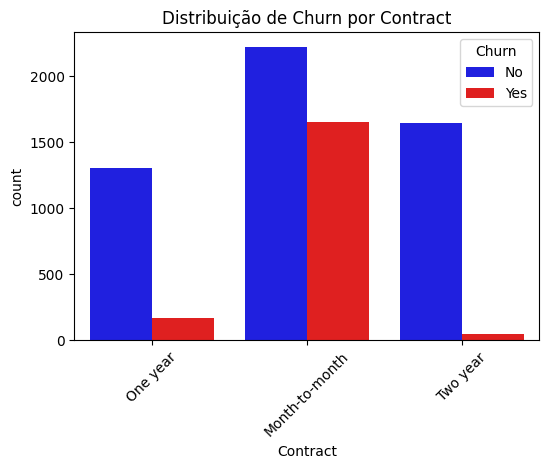

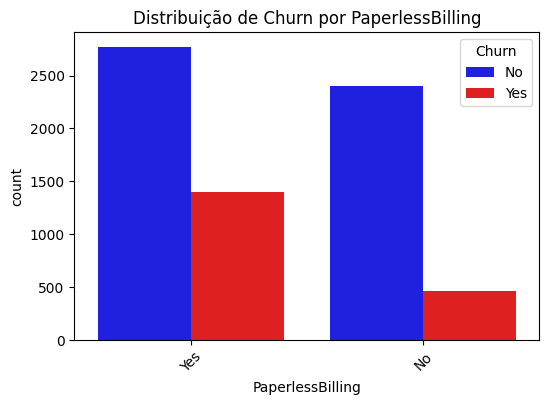

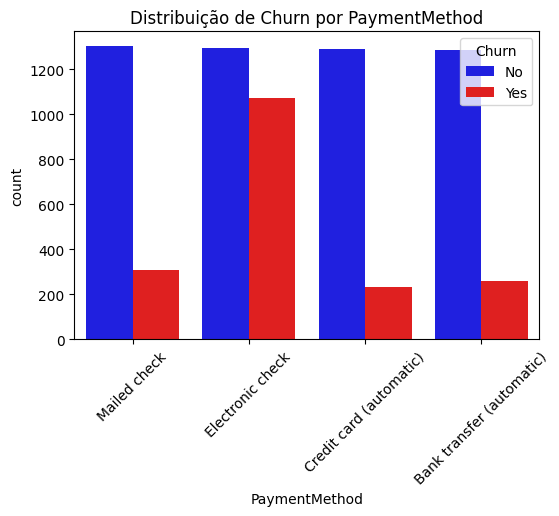

In [321]:
palette = {"No": "blue", "Yes": "red"}

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        palette=palette
    )
    plt.title(f"Distribuição de Churn por {col}")
    plt.xticks(rotation=45)
    plt.show()

## Separação dos dados / Encoding

### Variáveis explicativas e variável alvo


Para fazer a previsão dos valores com um modelo de machine learning, precisamos fazer a separação da variável alvo e variáveis explicativas. O y representa a variável que queremos prever, enquanto x representa todas as variáveis que serão utilizadas para explicar o comportamento de **y**.



In [322]:
# x = varivel explicativa
# y = variavel alvo (churn)

x = df.drop(columns='Churn', axis = 1)
y = df['Churn']

In [323]:
x

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,Male,No,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [324]:
y

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7038,No
7039,Yes
7040,No
7041,No


## Transformando as variáveis explicativas


Os algoritmos de machine learning não compreendem dados no formato de texto, portanto devemos fazer transformações nos dados para o formato numérico para que o algoritmo consiga compreender as informações. Essa transformação precisa ser feita de forma que não altere a informação original do conjunto de dados, portanto não basta simplesmente alterar os valores para valores numéricos aleatórios.


In [325]:
colunas = x.columns

one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'), ['Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    verbose_feature_names_out=False)

In [326]:
x = one_hot.fit_transform(x)
colunas = one_hot.get_feature_names_out(colunas)
colunas

array(['Gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'],
      dtype=object)

In [327]:
pd.DataFrame(x, columns=colunas)

,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,2.19,65.60,593.30
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,9.0,2.00,59.90,542.40
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,4.0,2.46,73.90,280.85
3,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,13.0,3.27,98.00,1237.85
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,13.0,1.84,55.15,742.90
7039,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,22.0,2.84,85.10,1873.70
7040,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1.68,50.30,92.75
7041,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,67.0,2.26,67.85,4627.65


In [328]:
label_encoder = LabelEncoder()
y  = label_encoder.fit_transform(y)
y

array([0, 0, 1, ..., 0, 0, 0])

# Ajustando modelos

### Dividindo os dados entre Treino e Teste

Para compreender se o modelo está de fato aprendendo com os dados, precisamos fazer uma separação dos dados entre treinamento e teste. Os dados de **treinamento** são usados para ajustar o modelo, enquanto os dados de **teste** servem para verificar o aprendizado do modelo em dados que não foram utilizados no momento do ajuste.


In [329]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, stratify = y,  random_state = 42)

# Normalização

In [330]:
scaler = StandardScaler()

In [331]:
x_treino_normalizado = scaler.fit_transform(x_treino)
x_teste_normalizado = scaler.transform(x_teste)

In [332]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

In [333]:
pd.DataFrame(x_treino_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.833333,0.755224,0.754360,0.630515
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.166667,0.008955,0.009467,0.024445
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.027778,0.617910,0.618336,0.015786
3,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.458333,0.561194,0.561535,0.282482
4,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.194444,0.674627,0.673642,0.134033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.305556,0.023881,0.023418,0.052085
5630,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.583333,0.755224,0.755356,0.482026
5631,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.277778,0.665672,0.666168,0.199717
5632,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.333333,0.062687,0.062780,0.065833


# Modelo de base

O modelo mais simples de classificar os dados é simplesmente utilizar um algoritmo que chuta todas as classificações para a classe que tem maior frequência. Esse algoritmo serve como um critério de comparação, para identificar se os outros modelos tem um desempenho melhor do que a classificação mais simples possível.


In [375]:
dummy = DummyClassifier(random_state=42)
dummy.fit(x_treino, y_treino)

y_pred_dummy = dummy.predict(x_teste)

print(classification_report(y_teste, y_pred_dummy, zero_division=0))

# dummy.score(x_teste, y_teste)

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



In [335]:
print("Acurácia Dummy:", accuracy_score(y_teste, y_pred_dummy))

Acurácia Dummy: 0.7345635202271115


# Árvore de decisão

O modelo de árvore de decisão é muito utilizado pela sua alta **explicabilidade** e **processamento rápido**, mantendo um desempenho bem interessante.

Ele se baseia em decisões simples tomadas pelo algoritmo, separando os dados com base em comparações de **menor** e **maior** nos valores das colunas da base de dados.

In [336]:
tree_model = DecisionTreeClassifier(
        max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42)

tree_model.fit(x_treino, y_treino)

tree_pred = tree_model.predict(x_teste)

print(classification_report(y_teste, tree_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.49      0.53       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [337]:
print("Acurácia Árvore:", accuracy_score(y_teste, tree_pred))

Acurácia Árvore: 0.7693399574166075


In [338]:
nome_colunas = [
    'Gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'
]

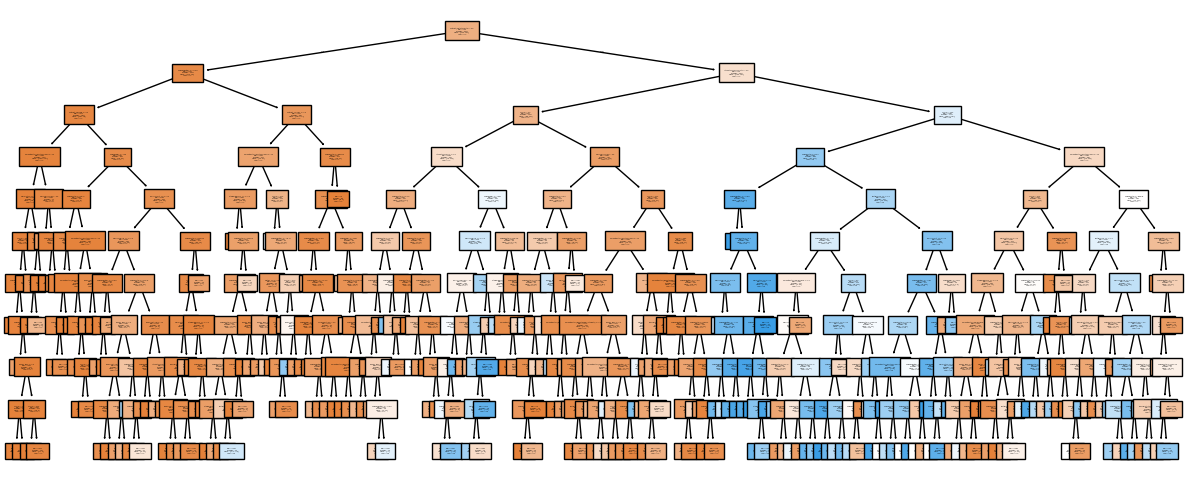

In [376]:
plt.figure(figsize = (15, 6))
plot_tree(tree_model, filled = True, class_names = ['nao', 'sim'], fontsize = 1, feature_names = nome_colunas);

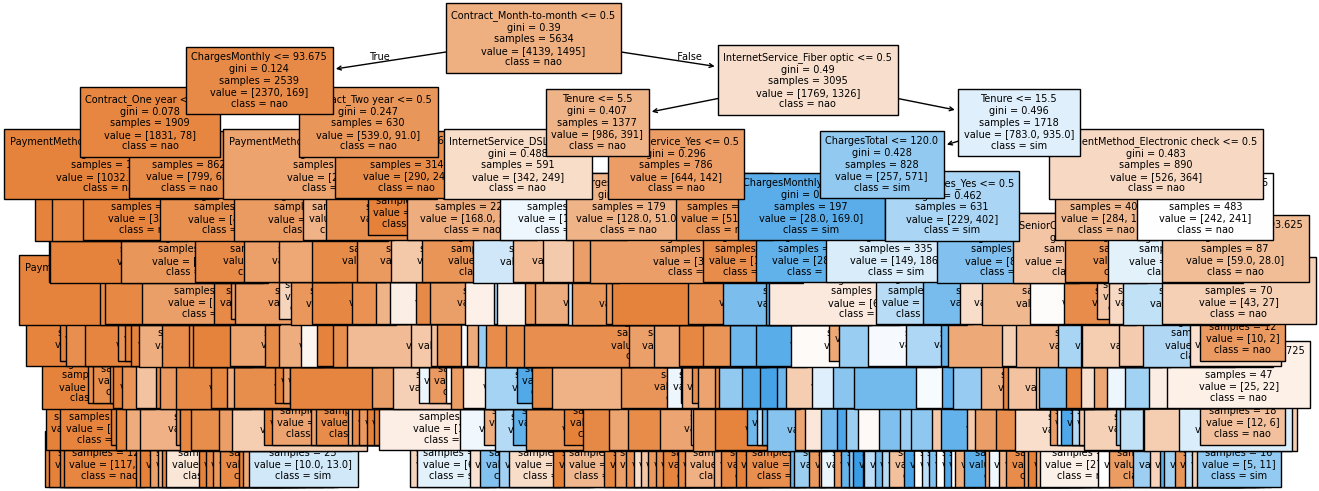

In [340]:
plt.figure(figsize = (15, 6))
plot_tree(tree_model, filled = True, class_names = ['nao', 'sim'], fontsize = 7, feature_names = nome_colunas);

# Random Forest

In [341]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5, max_features='sqrt', random_state=42)
rf_model.fit(x_treino, y_treino)

y_pred_rf = rf_model.predict(x_teste)

print("Random Forest")
print(classification_report(y_teste, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409



In [342]:
print("Acurácia Random Forest:", accuracy_score(y_teste, y_pred_rf))

Acurácia Random Forest: 0.794889992902768


# KNN

O algoritmo KNN se baseia no cálculo de distância entre os registros da base de dados e busca elementos que estejam próximos uns dos outros (vizinhos) para tomar a decisão da classificação.

Por conta de usar cálculos de distância, esse algoritmo é influenciado pela escala das variáveis e por conta disso é necessário uma transformação nos dados antes de utilizar esse método.

In [343]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_treino_normalizado, y_treino)

knn_pred = knn_model.predict(x_teste_normalizado)
print(classification_report(y_teste, knn_pred))

print("KNN:", accuracy_score(y_teste, knn_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1035
           1       0.55      0.57      0.56       374

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.76      0.76      0.76      1409

KNN: 0.7608232789212207


In [344]:
print("Acurácia KNN:", accuracy_score(y_teste, knn_pred))

Acurácia KNN: 0.7608232789212207


# Regressão logística

In [345]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_treino, y_treino)

y_pred_log_normal = log_model.predict(x_teste)

print("Regressão Logística")
print(classification_report(y_teste, y_pred_log_normal))


Regressão Logística
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [346]:
print("Acurácia Regressão Logística Normalizado:", accuracy_score(y_teste, y_pred_log_normal))

Acurácia Regressão Logística Normalizado: 0.7913413768630234


In [347]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(x_treino, y_treino)

y_pred_log = log_model.predict(x_teste)

print(classification_report(y_teste, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [348]:
print("Acurácia Regressão Logística:", accuracy_score(y_teste, y_pred_log))

Acurácia Regressão Logística: 0.7395315826827538


# Avaliação dos modelos

In [349]:
# Verificando as acurácias dos modelos

print("Acurácia Dummy:", accuracy_score(y_teste, y_pred_dummy))
print("Acurácia Árvore:", accuracy_score(y_teste, tree_pred))
print("Acurácia Random Forest:", accuracy_score(y_teste, y_pred_rf))
print("Acurácia KNN:", accuracy_score(y_teste, knn_pred))
print("Acurácia Regressão Logística:", accuracy_score(y_teste, y_pred_log_normal))
print("Acurácia Regressão Logística Normalizado:", accuracy_score(y_teste, y_pred_log))

Acurácia Dummy: 0.7345635202271115
Acurácia Árvore: 0.7693399574166075
Acurácia Random Forest: 0.794889992902768
Acurácia KNN: 0.7608232789212207
Acurácia Regressão Logística: 0.7913413768630234
Acurácia Regressão Logística Normalizado: 0.7395315826827538


In [350]:
# DF com as informações de treino, teste, precisão, recall, f1 e matriz de confusão

resultados = []

def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    print(f"\n===== {nome} =====")
    print(f"Acurácia Treino: {acc_train:.4f}")
    print(f"Acurácia Teste:  {acc_test:.4f}")
    print(f"Precisão:        {precision:.4f}")
    print(f"Recall:          {recall:.4f}")
    print(f"F1-Score:        {f1:.4f}")

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

    resultados.append({
        "Modelo": nome,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test,
        "Precisão": precision,
        "Recall": recall,
        "F1-Score": f1
    })


===== Árvore de Decisão =====
Acurácia Treino: 0.8419
Acurácia Teste:  0.7693
Precisão:        0.5763
Recall:          0.4947
F1-Score:        0.5324


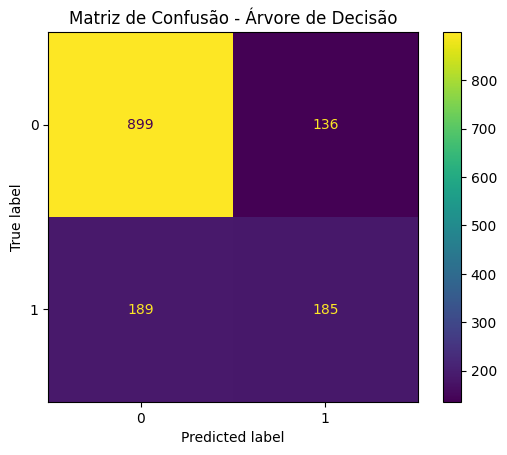


===== Random Forest =====
Acurácia Treino: 0.8490
Acurácia Teste:  0.7949
Precisão:        0.6471
Recall:          0.5000
F1-Score:        0.5641


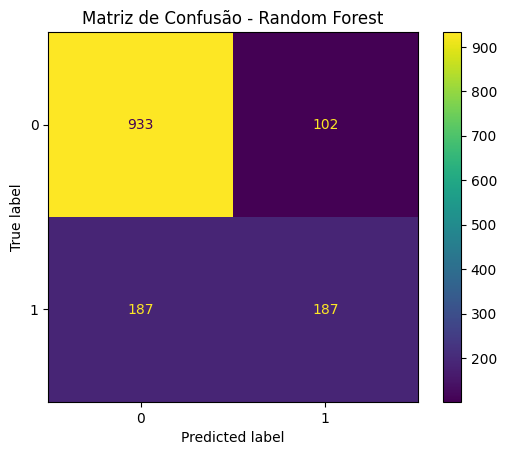


===== KNN =====
Acurácia Treino: 0.8294
Acurácia Teste:  0.7608
Precisão:        0.5473
Recall:          0.5722
F1-Score:        0.5595


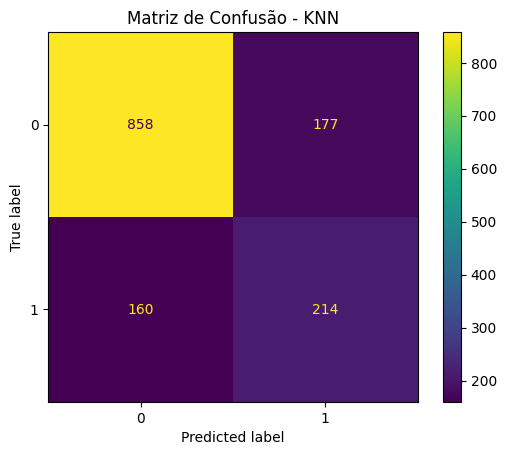


===== Regressão Logística =====
Acurácia Treino: 0.7522
Acurácia Teste:  0.7395
Precisão:        0.5060
Recall:          0.7888
F1-Score:        0.6165


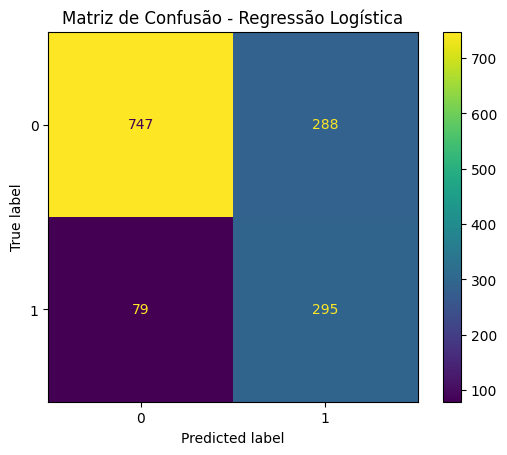

,Modelo,Acurácia Treino,Acurácia Teste,Precisão,Recall,F1-Score
0,Árvore de Decisão,0.841853,0.769340,0.576324,0.494652,0.532374
1,Random Forest,0.848953,0.794890,0.647059,0.500000,0.564103
2,KNN,0.829428,0.760823,0.547315,0.572193,0.559477
3,Regressão Logística,0.752219,0.739532,0.506003,0.788770,0.616510


In [351]:
resultados = []

# Árvore de Decisão
avaliar_modelo(
    "Árvore de Decisão",
    tree_model,
    x_treino,
    x_teste,
    y_treino,
    y_teste
)

# Random Forest
avaliar_modelo(
    "Random Forest",
    rf_model,
    x_treino,
    x_teste,
    y_treino,
    y_teste
)

# KNN (usa dados normalizados)
avaliar_modelo(
    "KNN",
    knn_model,
    x_treino_normalizado,
    x_teste_normalizado,
    y_treino,
    y_teste
)

# Regressão Logística
avaliar_modelo(
    "Regressão Logística",
    log_model,
    x_treino,
    x_teste,
    y_treino,
    y_teste
)

# Criar DataFrame comparativo
df_resultados = pd.DataFrame(resultados)
df_resultados

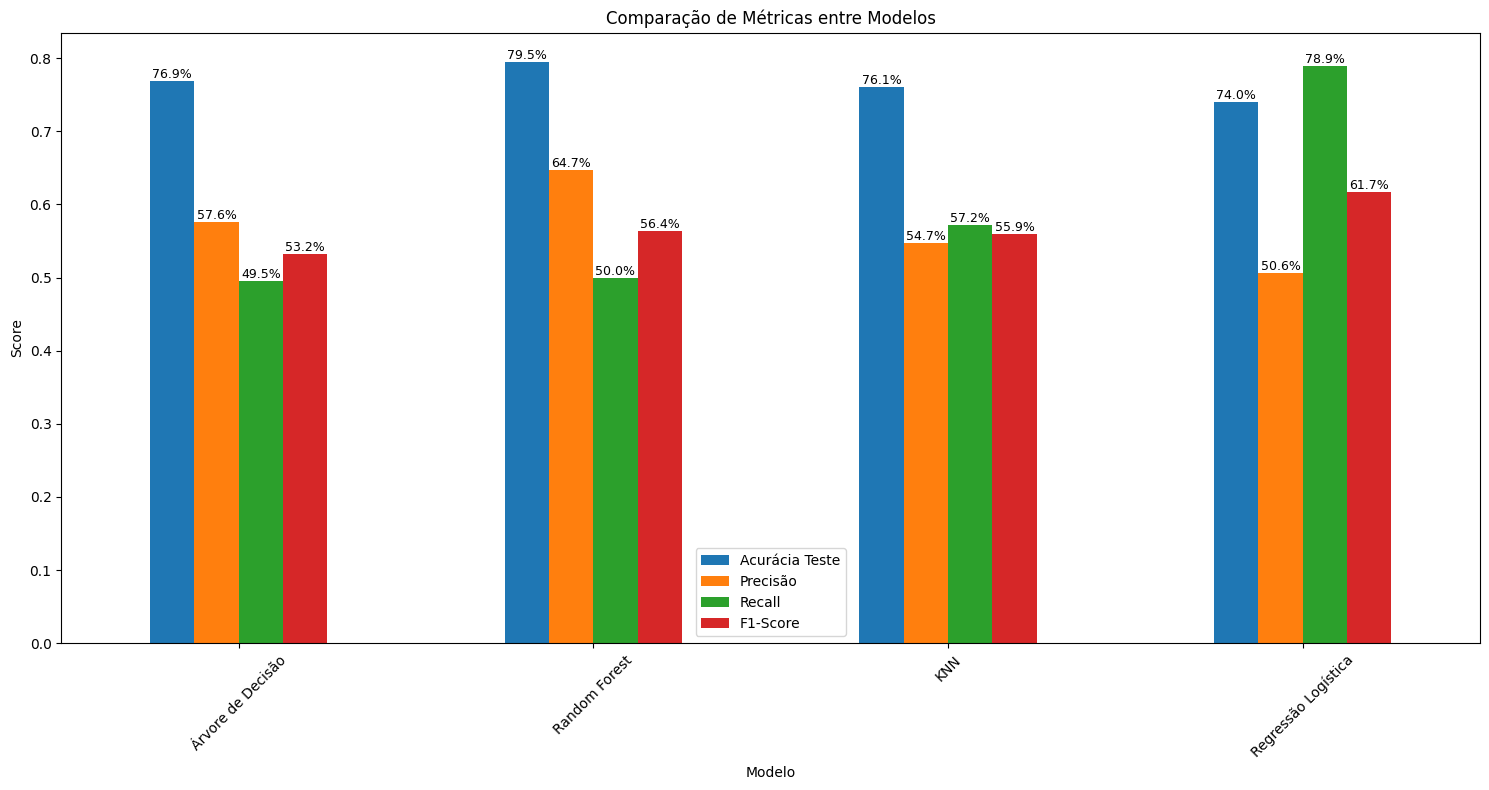

In [353]:
# Gráfico das avaliações

ax = df_resultados.set_index("Modelo")[[
    "Acurácia Teste", "Precisão", "Recall", "F1-Score"
]].plot(kind="bar", figsize=(15, 8))

plt.title("Comparação de Métricas entre Modelos")
plt.ylabel("Score")
plt.xticks(rotation=45)

# Adicionando porcentagem nas barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height*100:.1f}%',  # multiplica por 100 se estiver entre 0 e 1
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=9)

plt.tight_layout()
plt.show()

## Avaliando separadamente para verificar se existe overfiting ou underfiting

In [354]:
#Avaliação – Regressão Logística

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Métricas - Teste
acc_log = accuracy_score(y_teste, y_pred_log)
prec_log = precision_score(y_teste, y_pred_log)
rec_log = recall_score(y_teste, y_pred_log)
f1_log = f1_score(y_teste, y_pred_log)
cm_log = confusion_matrix(y_teste, y_pred_log)

print("=== Regressão Logística ===")
print("Acurácia:", acc_log)
print("Precisão:", prec_log)
print("Recall:", rec_log)
print("F1-score:", f1_log)
print("Matriz de Confusão:\n", cm_log)

=== Regressão Logística ===
Acurácia: 0.7395315826827538
Precisão: 0.5060034305317325
Recall: 0.7887700534759359
F1-score: 0.6165099268547545
Matriz de Confusão:
 [[747 288]
 [ 79 295]]


In [355]:
accuracy_score(y_treino, log_model.predict(x_treino))

0.7522186723464679

In [356]:
#Avaliação – Random Forest

# Métricas - Teste
acc_rf = accuracy_score(y_teste, y_pred_rf)
prec_rf = precision_score(y_teste, y_pred_rf)
rec_rf = recall_score(y_teste, y_pred_rf)
f1_rf = f1_score(y_teste, y_pred_rf)
cm_rf = confusion_matrix(y_teste, y_pred_rf)

print("\n=== Random Forest ===")
print("Acurácia:", acc_rf)
print("Precisão:", prec_rf)
print("Recall:", rec_rf)
print("F1-score:", f1_rf)
print("Matriz de Confusão:\n", cm_rf)


=== Random Forest ===
Acurácia: 0.794889992902768
Precisão: 0.6470588235294118
Recall: 0.5
F1-score: 0.5641025641025641
Matriz de Confusão:
 [[933 102]
 [187 187]]


In [357]:
accuracy_score(y_treino, rf_model.predict(x_treino))

0.8489527866524672

In [358]:
#Avaliação – KNN

# Métricas - Teste
acc_knn = accuracy_score(y_teste, knn_pred)
prec_knn = precision_score(y_teste, knn_pred)
rec_knn = recall_score(y_teste, knn_pred)
f1_knn = f1_score(y_teste, knn_pred)
cm_knn = confusion_matrix(y_teste, knn_pred)

print("\n=== KNN ===")
print("Acurácia:", acc_knn)
print("Precisão:", prec_knn)
print("Recall:", rec_knn)
print("F1-score:", f1_knn)
print("Matriz de Confusão:\n", cm_knn)


=== KNN ===
Acurácia: 0.7608232789212207
Precisão: 0.5473145780051151
Recall: 0.5721925133689839
F1-score: 0.5594771241830065
Matriz de Confusão:
 [[858 177]
 [160 214]]


In [359]:
accuracy_score(y_treino, knn_model.predict(x_treino))

0.7346467873624423

In [360]:
#Avaliação – Árvore de decisão

# Métricas - Teste
acc_tree = accuracy_score(y_teste, tree_pred)
prec_tree = precision_score(y_teste, tree_pred)
rec_tree = recall_score(y_teste, tree_pred)
f1_tree = f1_score(y_teste, tree_pred)
cm_tree = confusion_matrix(y_teste, tree_pred)

print("\n=== Árvore de Decisão ===")
print("Acurácia:", acc_tree)
print("Precisão:", prec_tree)
print("Recall:", rec_tree)
print("F1-score:", f1_tree)
print("Matriz de Confusão:\n", cm_tree)


=== Árvore de Decisão ===
Acurácia: 0.7693399574166075
Precisão: 0.5763239875389408
Recall: 0.4946524064171123
F1-score: 0.5323741007194245
Matriz de Confusão:
 [[899 136]
 [189 185]]


In [361]:
accuracy_score(y_treino, tree_model.predict(x_treino))

0.84185303514377

Após verificação foi constatado que nos resultados de treino da árvore de decisão e no random forest estavam com overfiting, foi aplicado alguns parâmetros para que isso fosse corrigido, e agora os resultados estão dentro do esperado

# Análise de Importância das Variáveis

## Regressão Logística:
Investigando os coeficientes das variáveis que contribuem para a previsão de evasão.

In [407]:
# Importância das Variáveis - Regressão Logística

coeficientes_log = pd.DataFrame({
    "Variável": colunas,
    "Coeficiente": log_model.coef_[0]
})

coeficientes_log["Impacto_Absoluto"] = np.abs(coeficientes_log["Coeficiente"])

coeficientes_log = coeficientes_log.sort_values(
    by="Impacto_Absoluto",
    ascending=False
)

coeficientes_log["Odds_Ratio"] = np.exp(coeficientes_log["Coeficiente"])
coeficientes_log.head(10)


,Variável,Coeficiente,Impacto_Absoluto,Odds_Ratio
4,PhoneService_Yes,-0.772304,0.772304,0.461947
15,Contract_Month-to-month,0.728986,0.728986,2.072979
17,Contract_Two year,-0.700963,0.700963,0.496107
12,TechSupport_Yes,-0.463969,0.463969,0.628783
8,InternetService_No,-0.446523,0.446523,0.639849
7,InternetService_Fiber optic,0.437740,0.437740,1.549202
9,OnlineSecurity_Yes,-0.382489,0.382489,0.682161
18,PaperlessBilling_Yes,0.346791,0.346791,1.414521
21,PaymentMethod_Electronic check,0.321692,0.321692,1.379460
10,OnlineBackup_Yes,-0.235930,0.235930,0.789836


Coeficiente positivo → aumenta chance de evasão

Coeficiente negativo → reduz chance de evasão

Maior valor absoluto → maior influência

## KNN:
KNN (K-Nearest Neighbors): Observe como os vizinhos mais próximos influenciam a decisão de classificação. As variáveis mais impactantes podem ser aquelas que mais contribuem para a proximidade entre os pontos de dados.

In [392]:
distancias, indices = knn_model.kneighbors(x_teste_normalizado[:1])

print("Número de vizinhos utilizados:", knn_model.n_neighbors)
print("Índices dos vizinhos:", indices)
print("Distâncias:", distancias)

variancia_knn = pd.DataFrame({
    "Variável": colunas,
    "Variância": pd.DataFrame(x_treino_normalizado, columns=colunas).var()
})

variancia_knn = variancia_knn.sort_values(
    by="Variância",
    ascending=False
)

variancia_knn.head(10)

Número de vizinhos utilizados: 5
Índices dos vizinhos: [[3824 4678 4285 2388 3002]]
Distâncias: [[5.16927034 5.17554588 5.21548553 5.34792765 5.3507042 ]]


,Variável,Variância
Gender_Male,Gender_Male,0.249981
Partner_Yes,Partner_Yes,0.249598
Contract_Month-to-month,Contract_Month-to-month,0.247609
InternetService_Fiber optic,InternetService_Fiber optic,0.246737
MultipleLines_Yes,MultipleLines_Yes,0.243889
PaperlessBilling_Yes,PaperlessBilling_Yes,0.240582
StreamingMovies_Yes,StreamingMovies_Yes,0.238165
StreamingTV_Yes,StreamingTV_Yes,0.237932
OnlineBackup_Yes,OnlineBackup_Yes,0.226523
InternetService_DSL,InternetService_DSL,0.225477


Variáveis com maior variação após normalização tendem a influenciar mais a distância

No KNN, proximidade define a classificação

# Random Forest:
Random Forest: Utilize a importância das variáveis fornecida pelo modelo. O Random Forest calcula a importância com base em como cada variável contribui para a redução da impureza durante as divisões das árvores.

In [365]:
# Importância das Variáveis - Random Forest

importancia_rf = pd.DataFrame({
    "Variável": colunas,
    "Importância": rf_model.feature_importances_
})

importancia_rf = importancia_rf.sort_values(
    by="Importância",
    ascending=False
)

importancia_rf.head(10)

,Variável,Importância
23,Tenure,0.168000
26,ChargesTotal,0.133167
15,Contract_Month-to-month,0.129426
25,ChargesMonthly,0.086512
24,ChargesDaily,0.084205
7,InternetService_Fiber optic,0.061199
21,PaymentMethod_Electronic check,0.057276
17,Contract_Two year,0.049047
8,InternetService_No,0.026694
18,PaperlessBilling_Yes,0.020792


Quanto maior a importância → maior redução de impureza nas árvores

Valores próximos de zero → pouca relevância

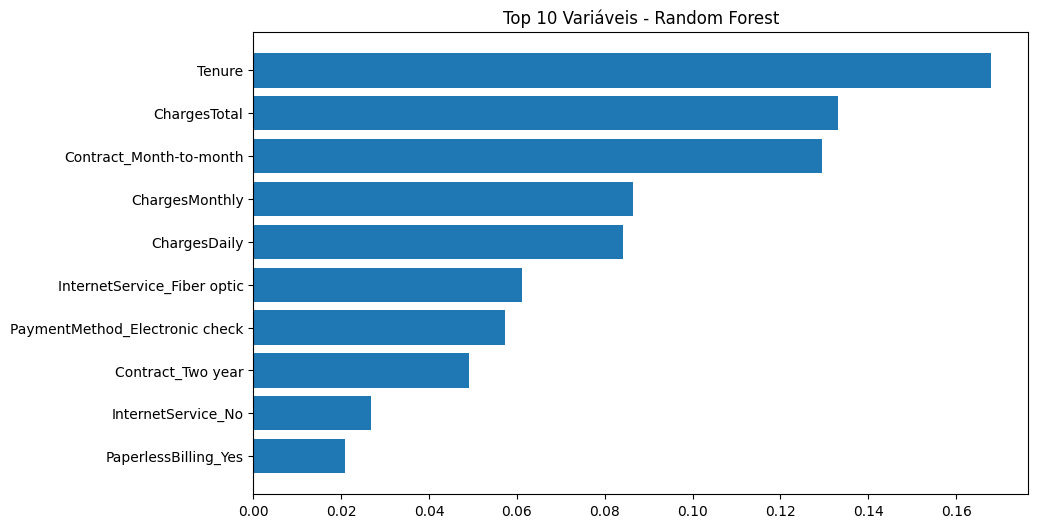

In [366]:
plt.figure(figsize=(10,6))
plt.barh(importancia_rf["Variável"][:10], importancia_rf["Importância"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Variáveis - Random Forest")
plt.show()

# Árvore de decisão

In [397]:
# Extraindo importâncias
importancias_arvore = tree_model.feature_importances_

# Criando DataFrame
df_arvore = pd.DataFrame({
    'Variavel': colunas,
    'Importancia': importancias_arvore
}).sort_values(by='Importancia', ascending=False)

df_arvore.head(10)

,Variavel,Importancia
15,Contract_Month-to-month,0.368331
23,Tenure,0.138140
26,ChargesTotal,0.114247
7,InternetService_Fiber optic,0.104430
25,ChargesMonthly,0.069434
24,ChargesDaily,0.031729
21,PaymentMethod_Electronic check,0.023610
5,MultipleLines_Yes,0.021736
6,InternetService_DSL,0.019824
0,Gender_Male,0.016281


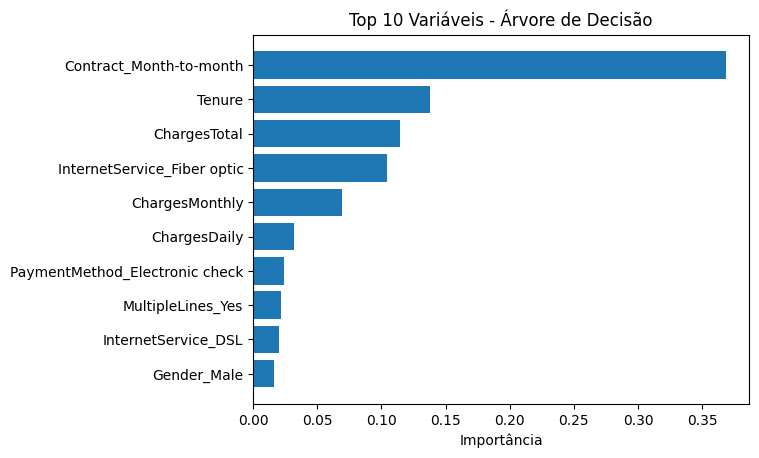

In [373]:
# Visualizando com gráfico

plt.figure()
plt.barh(df_arvore['Variavel'][:10], df_arvore['Importancia'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Variáveis - Árvore de Decisão')
plt.xlabel('Importância')
plt.show()

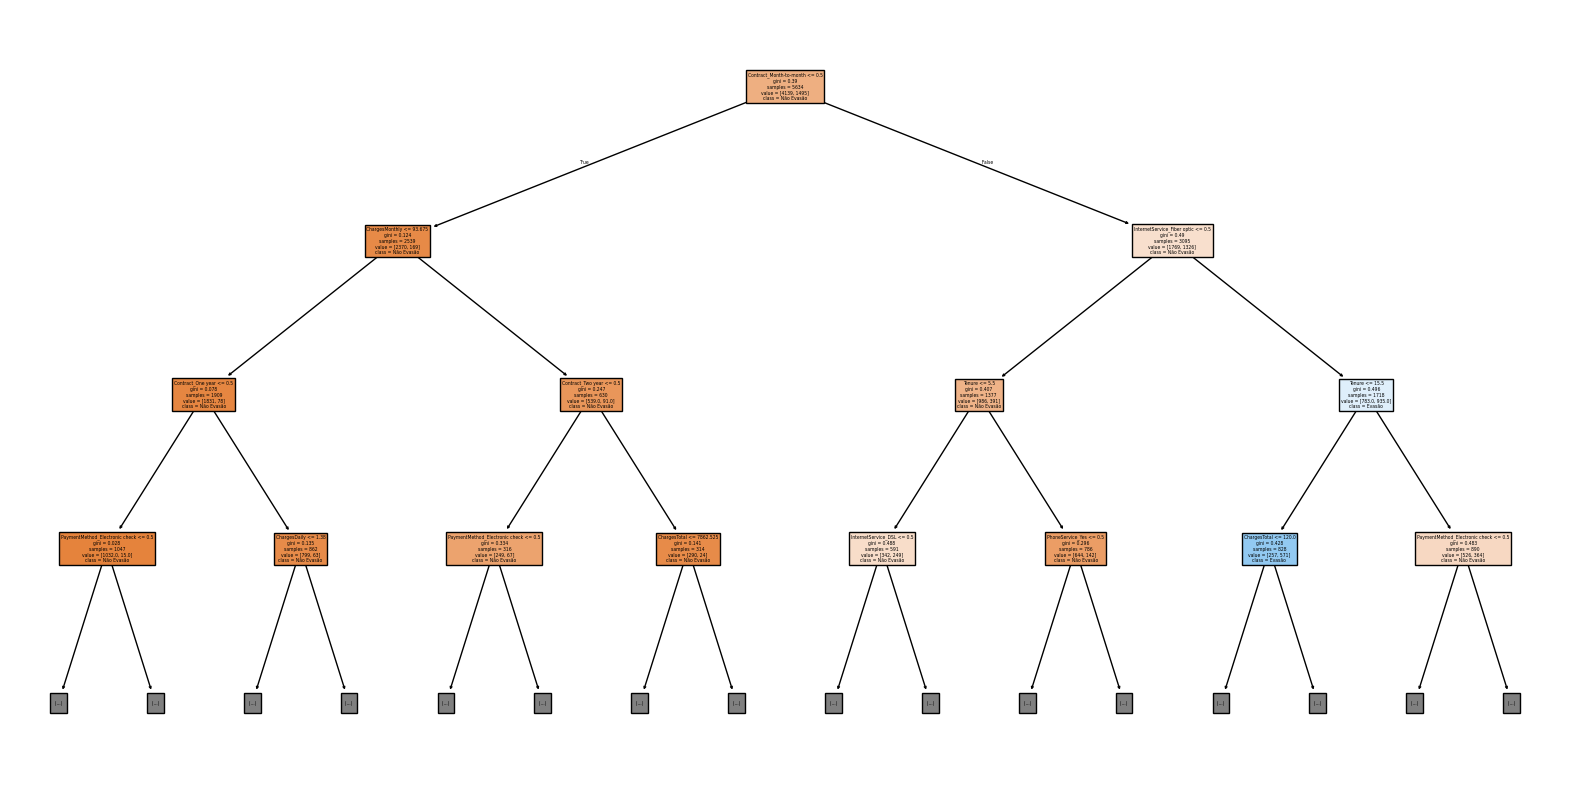

In [387]:
# Estrutura da árvore

plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=colunas,
    class_names=['Não Evasão', 'Evasão'],
    filled=True,
    max_depth=3
)
plt.show()

In [386]:
# Comparando a importância da Árvore de decisão com Random Forest

importancia_rf_renamed = importancia_rf.rename(columns={'Variável': 'Variavel', 'Importância': 'Importancia'})

comparacao = df_arvore.merge(
    importancia_rf_renamed,
    on='Variavel',
    suffixes=('_Arvore', '_RandomForest')
).sort_values(by='Importancia_Arvore', ascending=False)

comparacao.head(10)

,Variavel,Importancia_Arvore,Importancia_RandomForest
0,Contract_Month-to-month,0.368331,0.129426
1,Tenure,0.138140,0.168000
2,ChargesTotal,0.114247,0.133167
3,InternetService_Fiber optic,0.104430,0.061199
4,ChargesMonthly,0.069434,0.086512
5,ChargesDaily,0.031729,0.084205
6,PaymentMethod_Electronic check,0.023610,0.057276
7,MultipleLines_Yes,0.021736,0.011354
8,InternetService_DSL,0.019824,0.016538
9,Gender_Male,0.016281,0.011211


A Árvore de Decisão mostra quais variáveis são decisivas para as primeiras divisões.

Se as variáveis importantes coincidirem com o Random Forest, isso reforça a relevância delas.

Se houver diferenças, pode indicar instabilidade da árvore isolada (o que é esperado, já que o Random Forest reduz variância ao usar múltiplas árvores).

In [398]:
# Comparando os modelos

# Regressão Logística
coef_log = pd.DataFrame({
    "Variável": colunas,
    "Logistica_Coef": log_model.coef_[0]
})

coef_log["Logistica_Impacto"] = np.abs(coef_log["Logistica_Coef"])


# Random Forest
rf_importancia = pd.DataFrame({
    "Variável": colunas,
    "RF_Importancia": rf_model.feature_importances_
})


# KNN (baseado na variância após normalização)
variancia_knn = pd.DataFrame({
    "Variável": colunas,
    "KNN_Variancia": pd.DataFrame(x_treino_normalizado, columns=colunas).var()
})


# Unificando tudo
comparacao_modelos = coef_log.merge(rf_importancia, on="Variável")
comparacao_modelos = comparacao_modelos.merge(variancia_knn, on="Variável")

# Ordenando por importância da Random Forest
comparacao_modelos = comparacao_modelos.sort_values(
    by="RF_Importancia",
    ascending=False
)

comparacao_modelos.head(15)

,Variável,Logistica_Coef,Logistica_Impacto,RF_Importancia,KNN_Variancia
23,Tenure,-0.053594,0.053594,0.168000,0.116571
26,ChargesTotal,0.000284,0.000284,0.133167,0.068749
15,Contract_Month-to-month,0.728986,0.728986,0.129426,0.247609
25,ChargesMonthly,0.011256,0.011256,0.086512,0.089511
24,ChargesDaily,0.006380,0.006380,0.084205,0.089257
7,InternetService_Fiber optic,0.437740,0.437740,0.061199,0.246737
21,PaymentMethod_Electronic check,0.321692,0.321692,0.057276,0.222202
17,Contract_Two year,-0.700963,0.700963,0.049047,0.183246
8,InternetService_No,-0.446523,0.446523,0.026694,0.168368
18,PaperlessBilling_Yes,0.346791,0.346791,0.020792,0.240582


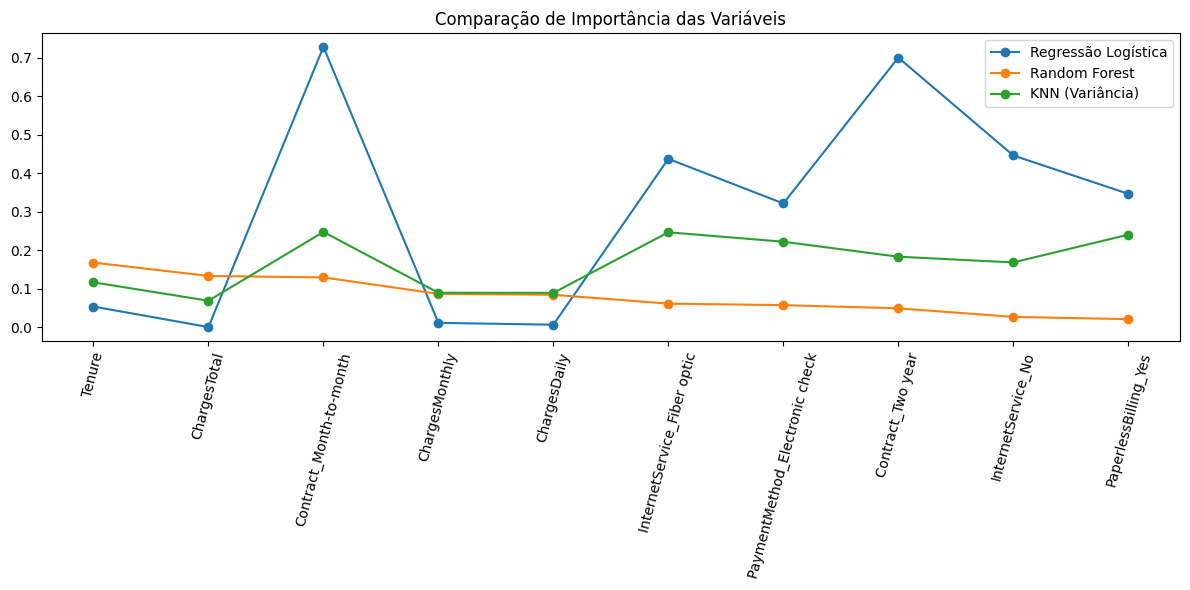

In [394]:
# Selecionando Top 10 variáveis da Random Forest
top_variaveis = comparacao_modelos.head(10)

plt.figure(figsize=(12,6))

plt.plot(top_variaveis["Variável"],
         top_variaveis["Logistica_Impacto"],
         marker='o', label="Regressão Logística")

plt.plot(top_variaveis["Variável"],
         top_variaveis["RF_Importancia"],
         marker='o', label="Random Forest")

plt.plot(top_variaveis["Variável"],
         top_variaveis["KNN_Variancia"],
         marker='o', label="KNN (Variância)")

plt.xticks(rotation=75)
plt.legend()
plt.title("Comparação de Importância das Variáveis")
plt.tight_layout()
plt.show()

# Relatório final
O objetivo deste projeto foi desenvolver modelos de Machine Learning capazes de prever a evasão de clientes (churn), permitindo à empresa TelecomX antecipar comportamentos e implementar estratégias de retenção.

Foram avaliados três modelos:

* Regressão Logística (log_model)
* KNN – K-Nearest Neighbors (knn_model)
* Random Forest (rf_model)
---
# 📈 Comparação Geral dos Modelos
1️⃣ Regressão Logística

## ✔ Pontos positivos

Modelo simples e interpretável

Permite análise direta dos coeficientes

Boa performance para relações lineares

Fácil implementação e baixo custo computacional

##✔ Interpretação

Os coeficientes mostram diretamente o impacto de cada variável na probabilidade de evasão, facilitando decisões estratégicas.

## ❗ Limitação
Pode não capturar relações complexas e não lineares entre variáveis.

---

## 2️⃣ KNN (K-Nearest Neighbors)

## ✔ Pontos positivos

* Modelo intuitivo
* Não assume linearidade
* Baseado em proximidade entre clientes similares

## ✔ Interpretação

A classificação depende dos vizinhos mais próximos no espaço de características normalizado.

## ❗ Limitações

* Sensível à escala dos dados
* Alto custo computacional para grandes bases
* Não fornece importância direta das variáveis
* Pode perder desempenho em bases com muitas variáveis (alta dimensionalidade)

---

## 3️⃣ Random Forest
## ✔ Pontos positivos

* Captura relações não lineares
* Robusto a ruídos e outliers
* Reduz overfitting em comparação com uma única árvore
* Fornece importância das variáveis
* Excelente desempenho preditivo

## ✔ Interpretação

O modelo calcula a importância das variáveis com base na redução de impureza nas divisões das árvores.

## ✔ Vantagem estratégica

Identifica automaticamente interações complexas entre variáveis que modelos lineares não capturam.

---

# 🏆 Melhor Modelo: Random Forest

Com base na comparação de métricas de desempenho (acurácia, recall, precisão e F1-score) e na capacidade de generalização observada nos dados de teste, o Random Forest (rf_model) se destacou como o melhor modelo.

## 🔎 Justificativa Técnica

* Apresentou melhor equilíbrio entre precisão e recall.
* Captura padrões não lineares presentes no comportamento de evasão.
* Demonstrou maior robustez frente à complexidade do dataset.
* Fornece ranking de importância das variáveis, permitindo análise estratégica.

---

# 📌 Consideração Importante sobre Recall

Em problemas de churn, identificar corretamente clientes que irão evadir (Recall da classe 1) é mais importante do que simplesmente maximizar a acurácia.

O Random Forest apresentou melhor capacidade de identificar clientes com risco de evasão, tornando-o mais adequado para uso estratégico.

---

# 🧠 Conclusão Final

Embora a Regressão Logística ofereça excelente interpretabilidade e o KNN forneça uma abordagem baseada em similaridade, o Random Forest apresentou melhor desempenho geral e maior capacidade de capturar padrões complexos nos dados.

Portanto, recomenda-se o uso do Random Forest como modelo final para previsão de evasão, podendo ser utilizado para:

* Identificação de clientes de alto risco
* Criação de campanhas de retenção direcionadas
* Apoio à tomada de decisão estratégica